### **Definición del proyecto**













#### **Planteamiento del problema**

¿Qué perfiles de pacientes diabéticos hospitalizados pueden identificarse a partir de sus características demográficas, clínicas y de uso de servicios de salud?

#### **Objetivo general**

Caracterizar los perfiles de pacientes diabéticos hospitalizados mediante el análisis exploratorio de sus variables demográficas, clínicas y de uso hospitalario, con el fin de identificar patrones relevantes en su comportamiento.

#### **Objetivos específicos**


*   Analizar la distribución de las variables demográficas y clínicas de los pacientes.
*   Identificar relaciones entre variables como tiempo de hospitalización, número de medicamentos y uso previo de servicios.
*   Detectar valores atípicos y evaluar su impacto en el análisis.
*   Aplicar técnicas de reducción de dimensionalidad o agrupamiento para identificar perfiles de pacientes.
*   Interpretar los patrones encontrados desde una perspectiva clínica y operativa.


### **Selección de la base de datos**

El conjunto de datos seleccionado corresponde a registros de pacientes diabéticos hospitalizados durante un periodo de diez años (1999–2008), incluyendo información clínica, demográfica y de uso de servicios de salud.
Este dataset es adecuado para el análisis propuesto debido a que:

*   Contiene 101766 registros, lo que permite identificar patrones significativos.
*   Incluye 50 variables relevantes como edad, género, número de medicamentos y tiempo de hospitalización.
*   Presenta diferentes tipos de datos (numéricos y categóricos), lo que facilita un análisis exploratorio completo.
*   Tiene una estructura clara donde cada fila representa un paciente y cada columna una variable.












#### Librerías necesarias

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Estrutura del dataset seleccionado**

In [31]:
df = pd.read_csv('/content/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### Número de registros y variables

In [32]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 101766
Número de variables: 50


#### Tipos de datos por variable

In [33]:
print(df.dtypes.value_counts())

object    37
int64     13
Name: count, dtype: int64


#### Clasificación de variables

In [34]:
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variables categóricas:")
print("\n".join([f"* {col}" for col in categoricas]))

print("\nVariables numéricas:")
print("\n".join([f"* {col}" for col in numericas]))

Variables categóricas:
* race
* gender
* age
* weight
* payer_code
* medical_specialty
* diag_1
* diag_2
* diag_3
* max_glu_serum
* A1Cresult
* metformin
* repaglinide
* nateglinide
* chlorpropamide
* glimepiride
* acetohexamide
* glipizide
* glyburide
* tolbutamide
* pioglitazone
* rosiglitazone
* acarbose
* miglitol
* troglitazone
* tolazamide
* examide
* citoglipton
* insulin
* glyburide-metformin
* glipizide-metformin
* glimepiride-pioglitazone
* metformin-rosiglitazone
* metformin-pioglitazone
* change
* diabetesMed
* readmitted

Variables numéricas:
* encounter_id
* patient_nbr
* admission_type_id
* discharge_disposition_id
* admission_source_id
* time_in_hospital
* num_lab_procedures
* num_procedures
* num_medications
* number_outpatient
* number_emergency
* number_inpatient
* number_diagnoses


#### Descripción de variables numéricas

In [35]:
print(df.describe())

       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%                    1.000000             7.00000

##### Valores faltantes

El dataset representa los valores faltantes con un símbolo `?`. Por eso, reemplazamos el símbolo por `NaN`

In [36]:
df.replace('?', np.nan, inplace=True)

faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])


Conteo de valores faltantes por variable:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


#### Variables más importantes para el problema planteado

In [37]:
variables_demograficas = ['race','gender','age','time_in_hospital','number_inpatient',
                          'number_outpatient','number_emergency', 'readmitted','num_medications',
                          'num_lab_procedures','diag_1','diag_2', 'diag_3']
print("\nVista rápida de variables clave (demográficas):")
print(df[variables_demograficas].head())
# Vista rápida de las variables clave
print("\nEstadísticas descriptivas de variables clave(demográficas):")
print(df[variables_demograficas].describe())


Vista rápida de variables clave (demográficas):
              race  gender      age  time_in_hospital  number_inpatient  \
0        Caucasian  Female   [0-10)                 1                 0   
1        Caucasian  Female  [10-20)                 3                 0   
2  AfricanAmerican  Female  [20-30)                 2                 1   
3        Caucasian    Male  [30-40)                 2                 0   
4        Caucasian    Male  [40-50)                 1                 0   

   number_outpatient  number_emergency readmitted  num_medications  \
0                  0                 0         NO                1   
1                  0                 0        >30               18   
2                  2                 0         NO               13   
3                  0                 0         NO               16   
4                  0                 0         NO                8   

   num_lab_procedures  diag_1  diag_2 diag_3  
0                  41  250.83   

### **Visualizaciones iniciales**

#### Distribución de variables numéricas

In [38]:
colors = ["#71dbd2", "#ade4b5", "#d0eaa3", "#fff18c"]
sns.set_palette(colors)

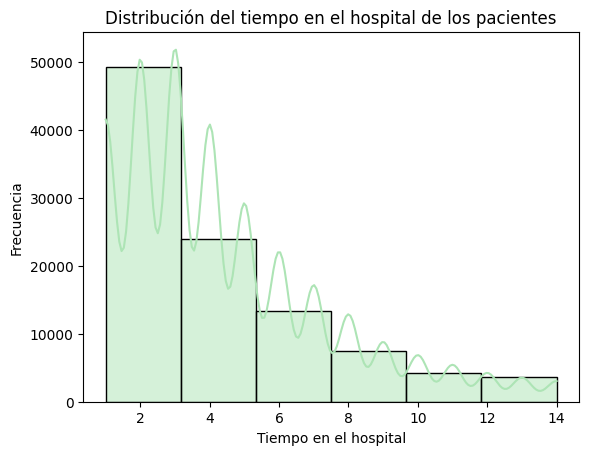

In [63]:
sns.histplot(df['time_in_hospital'], bins=6, kde=True, color='#ade4b5')
plt.title("Distribución del tiempo en el hospital de los pacientes")
plt.xlabel("Tiempo en el hospital")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_tiempo_hospital.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

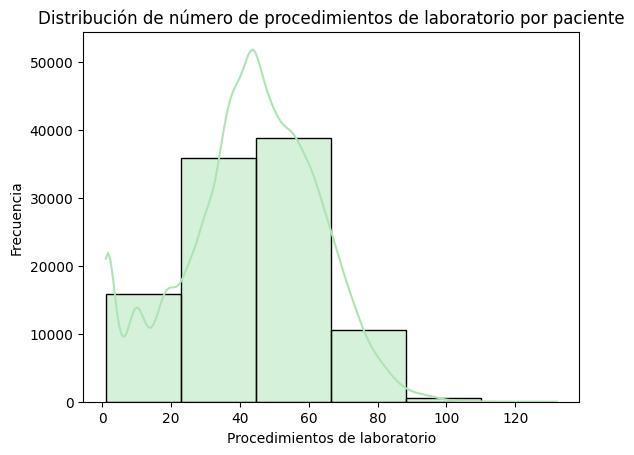

In [65]:
sns.histplot(df['num_lab_procedures'], bins=6, kde=True, color='#ade4b5')
plt.title("Distribución de número de procedimientos de laboratorio por paciente")
plt.xlabel("Procedimientos de laboratorio")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_lab_procedimientos.png', dpi=150, bbox_inches='tight')
plt.show()

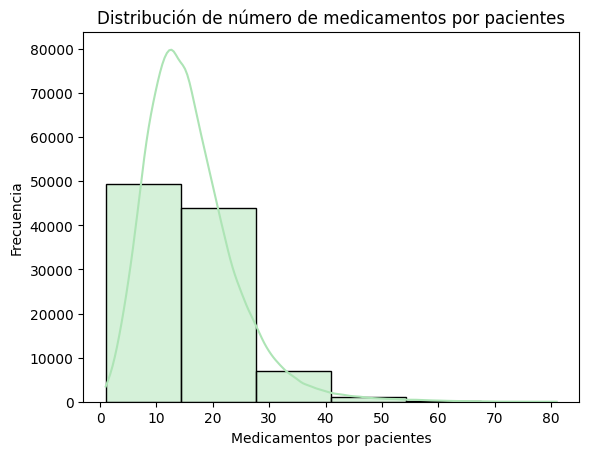

In [64]:
sns.histplot(df['num_medications'], bins=6, kde=True, color='#ade4b5')
plt.title("Distribución de número de medicamentos por pacientes")
plt.xlabel("Medicamentos por pacientes")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_med_pacientes.png', dpi=150, bbox_inches='tight')
plt.show()

#### Distribución variables categóricas


##### Género de los pacientes

/tmp/ipykernel_1143/2491433594.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(x='gender', data=df, hue='gender', palette=colors,legend=False)


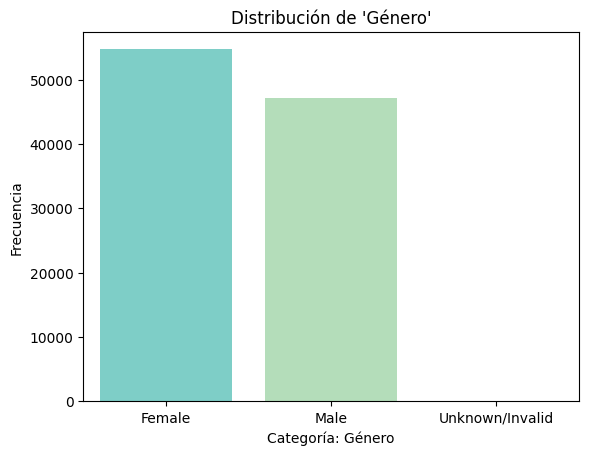

In [66]:
sns.countplot(x='gender', data=df, hue='gender', palette=colors,legend=False)
plt.title("Distribución de 'Género'")
plt.xlabel("Categoría: Género")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_genero.png', dpi=150, bbox_inches='tight')
plt.show()

##### Raza de los pacientes

/tmp/ipykernel_1143/3674438662.py:1: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='race', data=df, hue='race', palette=colors,legend=False)


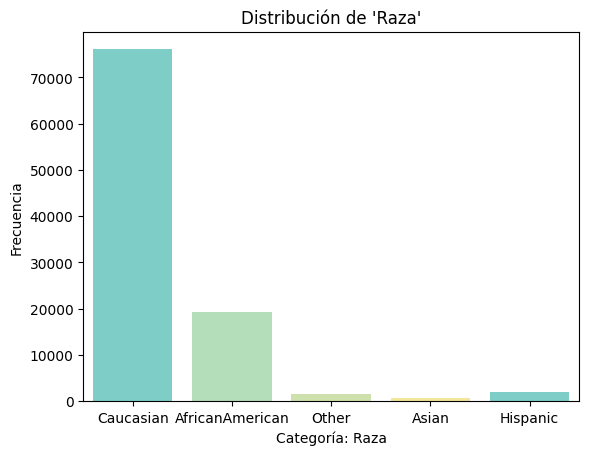

In [67]:
sns.countplot(x='race', data=df, hue='race', palette=colors,legend=False)
plt.title("Distribución de 'Raza'")
plt.xlabel("Categoría: Raza")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_raza.png', dpi=150, bbox_inches='tight')
plt.show()

##### Pacientes readmitidos

/tmp/ipykernel_1143/4199036543.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.countplot(x='readmitted', data=df, hue='readmitted', palette=colors,legend=False)


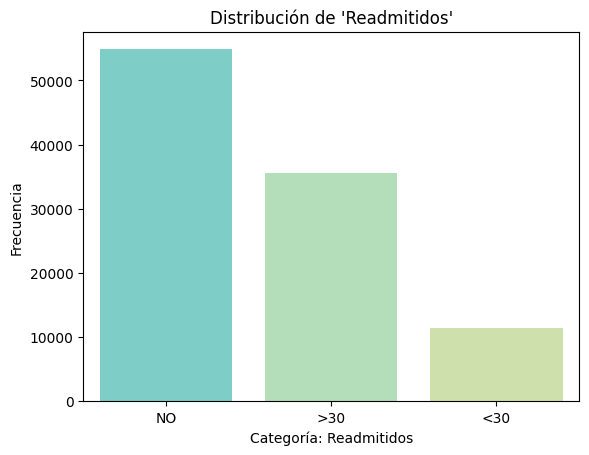

In [68]:
sns.countplot(x='readmitted', data=df, hue='readmitted', palette=colors,legend=False)
plt.title("Distribución de 'Readmitidos'")
plt.xlabel("Categoría: Readmitidos")
plt.ylabel("Frecuencia")
plt.savefig('/content/1.dist_readmitidos.png', dpi=150, bbox_inches='tight')
plt.show()

#### Boxplot para detección de outliers

In [46]:
numeric_cols = ['time_in_hospital', 'num_medications','num_lab_procedures']

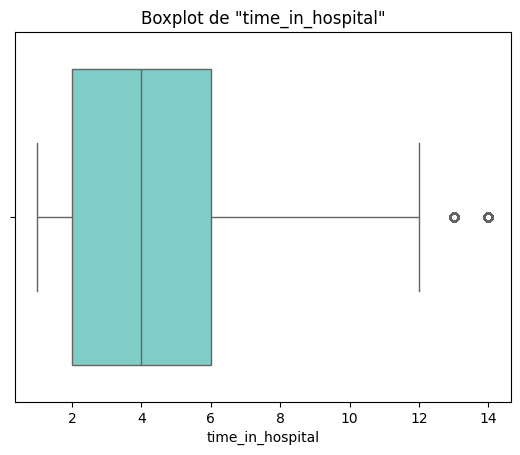

<Figure size 640x480 with 0 Axes>

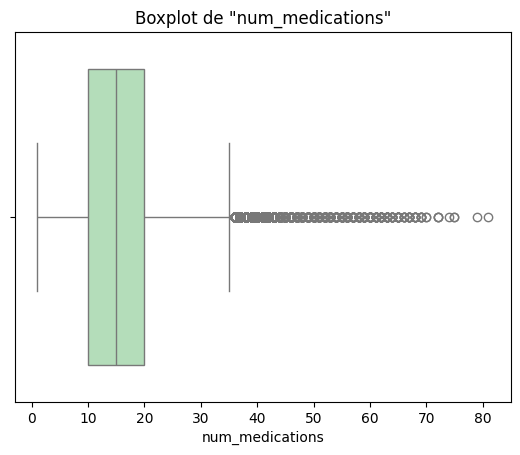

<Figure size 640x480 with 0 Axes>

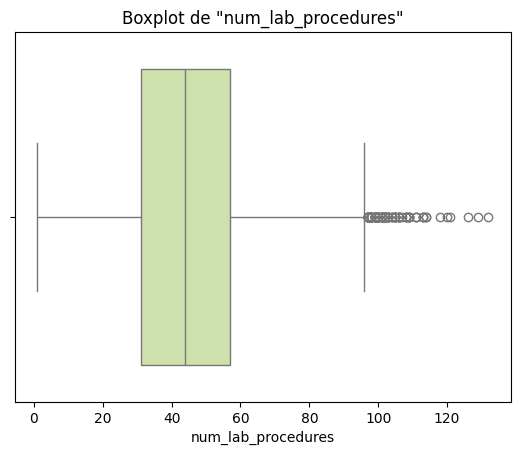

<Figure size 640x480 with 0 Axes>

In [47]:
for i, col in enumerate(numeric_cols):
    plt.figure()
    sns.boxplot(x=df[col].astype(float), color=colors[i % len(colors)])
    plt.title(f'Boxplot de "{col}"')
    plt.show()
    plt.savefig('/content/1.box_numericas.png', dpi=150, bbox_inches='tight')

#### Matriz de correlación

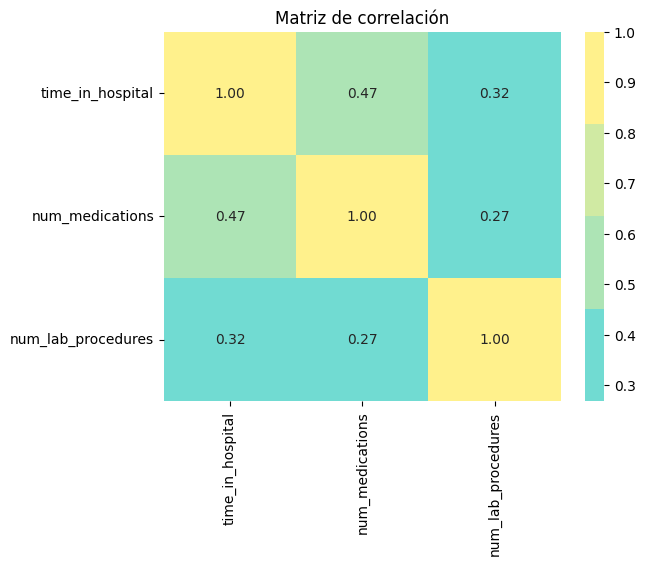

<Figure size 640x480 with 0 Axes>

In [48]:
plt.figure()
corr = df[numeric_cols].astype(float).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.color_palette(colors, as_cmap=True))
plt.title('Matriz de correlación')
plt.show()
plt.savefig('/content/1.matrix_corr.png', dpi=150, bbox_inches='tight')

### **Interpretaciones iniciales**

##### Tendencias y patrones básicos

*   La mayoría de los pacientes presenta estancias hospitalarias cortas, concentradas entre 1 y 7 días.
*   El número de medicamentos administrados muestra una alta variabilidad, con concentración en valores intermedios pero presencia de casos con valores elevados.
*   Se observan valores atípicos en variables como número de medicamentos y procedimientos, indicando casos clínicos más complejos o poco frecuentes.
*   Las variables relacionadas con el uso previo del sistema de salud (visitas ambulatorias, hospitalizaciones y emergencias) evidencian que existe un grupo de pacientes con alta recurrencia en los servicios médicos.





##### Observaciones sobre la base de datos

*   Algunas variables contienen valores faltantes representados como "?", lo que requiere procesos de limpieza e imputación.
*   Varias variables son categóricas codificadas (como los rangos de edad), lo que limita la precisión de ciertos análisis cuantitativos.
*   Existen valores atípicos en variables clave, lo que puede afectar medidas estadísticas como la media.
*   No todas las variables permiten establecer relaciones causales, ya que el dataset es observacional.
*   La información corresponde a hospitales de Estados Unidos entre 1999 y 2008, lo que puede limitar la generalización a otros contextos o periodos.









##### Hipótesis iniciales



*   Un mayor número de medicamentos administrados está asociado con un mayor tiempo de hospitalización.
*   Los pacientes con mayor número de procedimientos de laboratorio tienden a presentar estancias hospitalarias más largas.
*   Podrían existir diferencias en el uso de servicios o en la estancia hospitalaria según variables demográficas como edad, género o raza.









### Análisis bivariado

/tmp/ipykernel_1143/728285086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='time_in_hospital', data=df,


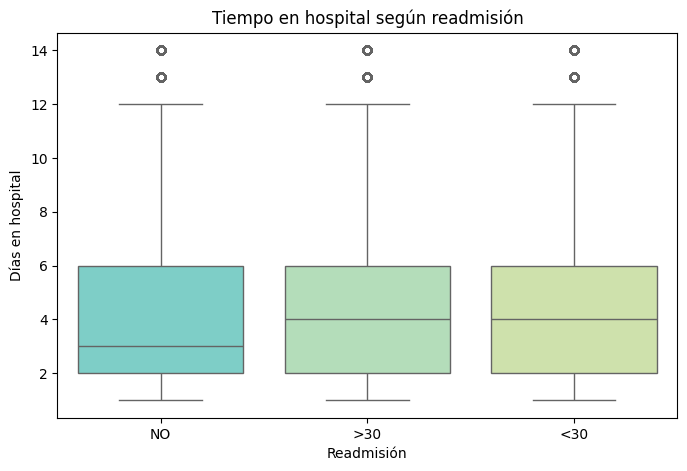

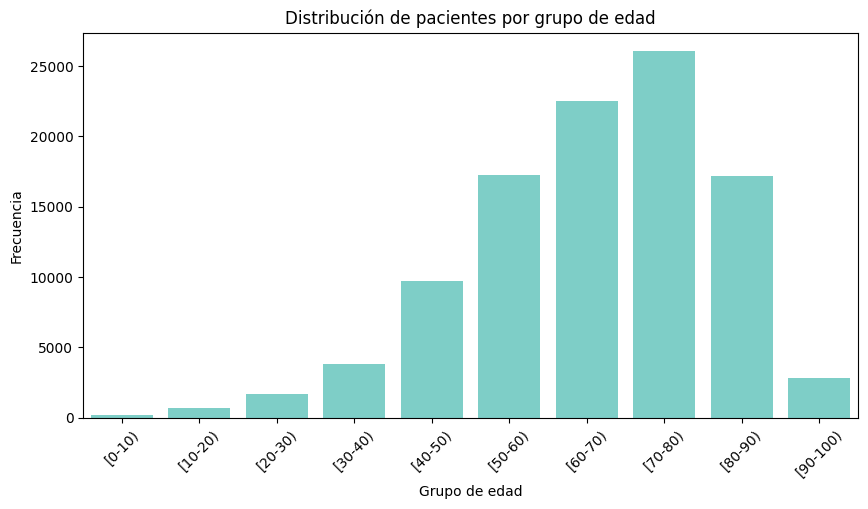

/tmp/ipykernel_1143/728285086.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='readmitted', y='num_medications', data=df,


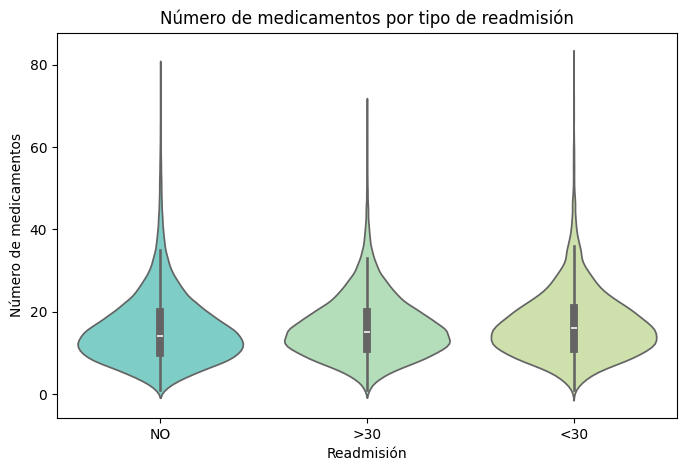

In [49]:
colors = ["#71dbd2", "#ade4b5", "#d0eaa3", "#fff18c"]

# 1. Tiempo en hospital por readmisión
plt.figure(figsize=(8, 5))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df,
            palette=colors[:3], order=['NO', '>30', '<30'])
plt.title('Tiempo en hospital según readmisión')
plt.xlabel('Readmisión')
plt.ylabel('Días en hospital')
plt.savefig('/content/2.biv_tiempo_readmision.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Distribución de edad (variable categórica ordinal)
orden_edad = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
              '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
plt.figure(figsize=(10, 5))
sns.countplot(x='age', data=df, order=orden_edad, color='#71dbd2')
plt.title('Distribución de pacientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.savefig('/content/2.biv_edad.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Número de medicamentos por readmisión
plt.figure(figsize=(8, 5))
sns.violinplot(x='readmitted', y='num_medications', data=df,
               palette=colors[:3], order=['NO', '>30', '<30'])
plt.title('Número de medicamentos por tipo de readmisión')
plt.xlabel('Readmisión')
plt.ylabel('Número de medicamentos')
plt.savefig('/content/2.biv_med_readmision.png', dpi=150, bbox_inches='tight')
plt.show()

## Análisis multivariado

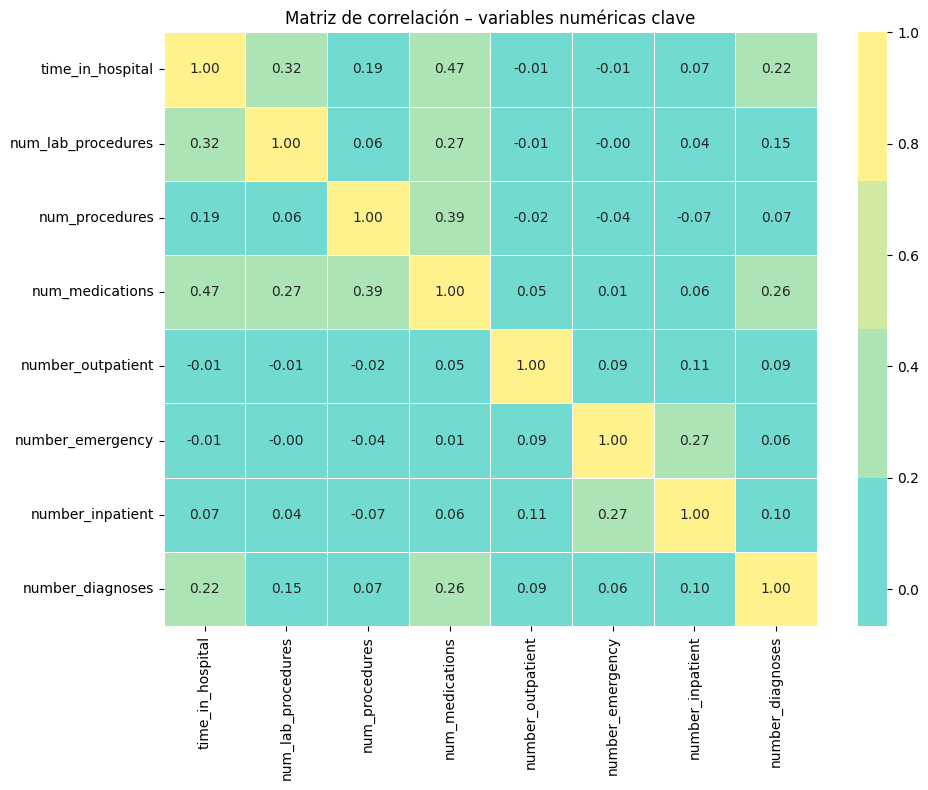

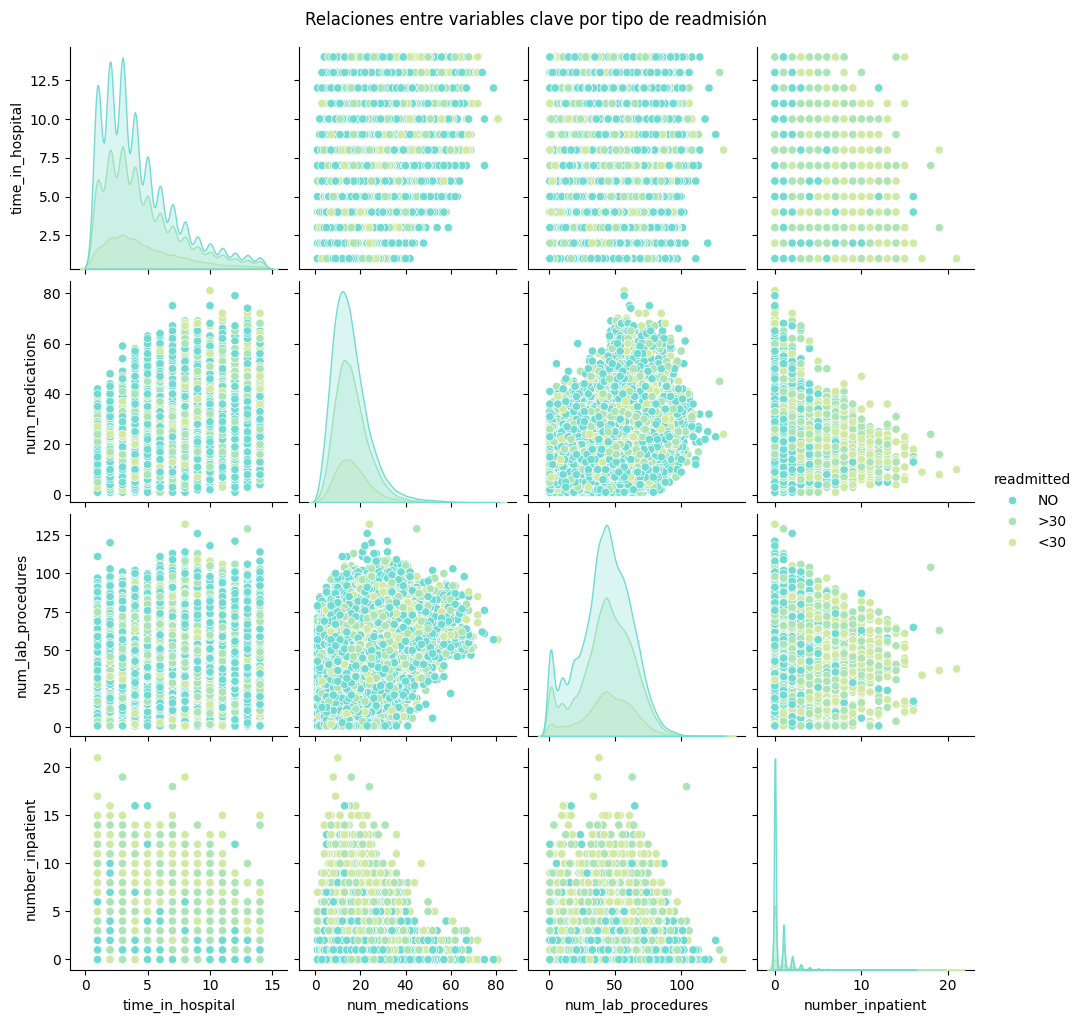

In [50]:
# 1. Matriz de correlación ampliada (todas las numéricas relevantes)
num_cols_completo = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                     'num_medications', 'number_outpatient', 'number_emergency',
                     'number_inpatient', 'number_diagnoses']

plt.figure(figsize=(10, 8))
corr = df[num_cols_completo].astype(float).corr()
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap=sns.color_palette(colors, as_cmap=True),
            linewidths=0.5)
plt.title('Matriz de correlación – variables numéricas clave')
plt.tight_layout()
plt.savefig('/content/2.multi_corr_ampliada.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Pairplot de las 4 variables más relevantes
pairplot_vars = ['time_in_hospital', 'num_medications',
                 'num_lab_procedures', 'number_inpatient', 'readmitted']
sns.pairplot(df[pairplot_vars].dropna(), hue='readmitted',
             palette={'NO': '#71dbd2', '>30': '#ade4b5', '<30': '#d0eaa3'})
plt.suptitle('Relaciones entre variables clave por tipo de readmisión', y=1.02)
plt.savefig('/content/2.multi_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Uso de medicamentos clave

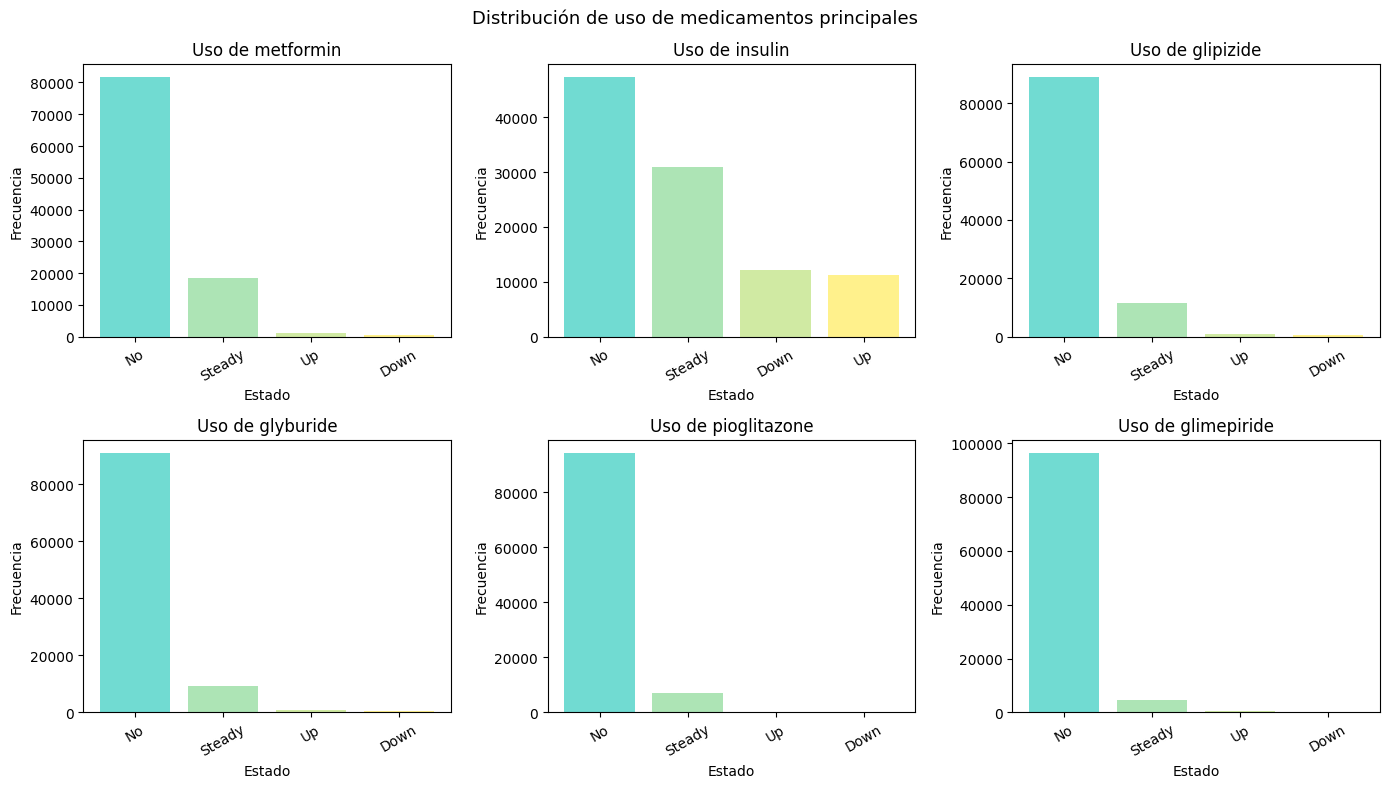

In [51]:
meds = ['metformin', 'insulin', 'glipizide', 'glyburide', 'pioglitazone', 'glimepiride']

# Frecuencia de cada estado por medicamento
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, med in zip(axes.flatten(), meds):
    counts = df[med].value_counts()
    ax.bar(counts.index, counts.values,
           color=['#71dbd2', '#ade4b5', '#d0eaa3', '#fff18c'][:len(counts)])
    ax.set_title(f'Uso de {med}')
    ax.set_xlabel('Estado')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Distribución de uso de medicamentos principales', fontsize=13)
plt.tight_layout()
plt.savefig('/content/2.multi_medicamentos.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocesamiento para clústeres

Antes de aplicar PCA y K-Means, es necesario:
1. Seleccionar las variables relevantes para la identificación de perfiles.
2. Codificar las variables categóricas.
3. Escalar las variables numéricas (K-Means es sensible a la escala).

In [52]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

colors = ["#71dbd2", "#ade4b5", "#d0eaa3", "#fff18c"]

#  3.1 Selección de variables
# Usamos variables con información clínica, demográfica y de uso de servicios.
# Excluimos IDs, diagnósticos ICD-9 crudos y medicamentos individuales
# (demasiado granulares y mayoritariamente con valor "No").

vars_clustering = [
    'age',                  # demográfica ordinal
    'gender',               # demográfica categórica
    'time_in_hospital',     # uso hospitalario
    'num_lab_procedures',   # intensidad diagnóstica
    'num_procedures',       # intervenciones
    'num_medications',      # carga farmacológica
    'number_outpatient',    # historial ambulatorio
    'number_emergency',     # historial urgencias
    'number_inpatient',     # historial hospitalizaciones
    'number_diagnoses',     # complejidad clínica
    'insulin',              # medicamento más frecuente
    'readmitted'            # resultado de interés
]

df_cluster = df[vars_clustering].copy()

print("Forma del subconjunto:", df_cluster.shape)
print("\nValores faltantes por variable:")
print(df_cluster.isnull().sum())

#  3.2 Tratamiento de valores faltantes
# 'gender' puede tener 'Unknown/Invalid' → se reemplaza por moda
df_cluster['gender'] = df_cluster['gender'].replace('Unknown/Invalid', np.nan)
df_cluster['gender'].fillna(df_cluster['gender'].mode()[0], inplace=True)

# Eliminamos filas con NaN restantes (son minoría)
df_cluster.dropna(inplace=True)
print(f"\nRegistros tras limpieza: {df_cluster.shape[0]}")

#  3.3 Codificación de variables categóricas

# Edad: variable ordinal  mapeo numérico
orden_edad = {
    '[0-10)': 0,  '[10-20)': 1, '[20-30)': 2,  '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6,  '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}
df_cluster['age'] = df_cluster['age'].map(orden_edad)

# Género: binario
df_cluster['gender'] = df_cluster['gender'].map({'Male': 0, 'Female': 1})

# Readmisión: ordinal (sin reingreso < reingreso tardío < reingreso temprano)
df_cluster['readmitted'] = df_cluster['readmitted'].map({'NO': 0, '>30': 1, '<30': 2})

# Insulina: ordinal (intensidad de prescripción)
df_cluster['insulin'] = df_cluster['insulin'].map({
    'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3
})

print("\nTipos tras codificación:")
print(df_cluster.dtypes)

# 3.4 Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("\nEscalado completado. Shape:", X_scaled.shape)

Forma del subconjunto: (101766, 12)

Valores faltantes por variable:
age                   0
gender                0
time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
insulin               0
readmitted            0
dtype: int64

Registros tras limpieza: 101766

Tipos tras codificación:
age                   int64
gender                int64
time_in_hospital      int64
num_lab_procedures    int64
num_procedures        int64
num_medications       int64
number_outpatient     int64
number_emergency      int64
number_inpatient      int64
number_diagnoses      int64
insulin               int64
readmitted            int64
dtype: object

Escalado completado. Shape: (101766, 12)


/tmp/ipykernel_1143/68204311.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cluster['gender'].fillna(df_cluster['gender'].mode()[0], inplace=True)


## Reducción de la dimensionalidad usando PCA

PCA transforma las 12 variables originales en componentes no correlacionados,
ordenados por varianza explicada. Esto permite:
- Eliminar redundancia entre variables correlacionadas.
- Proyectar los datos en 2D para visualización.
- Estabilizar el clustering al reducir el ruido dimensional.


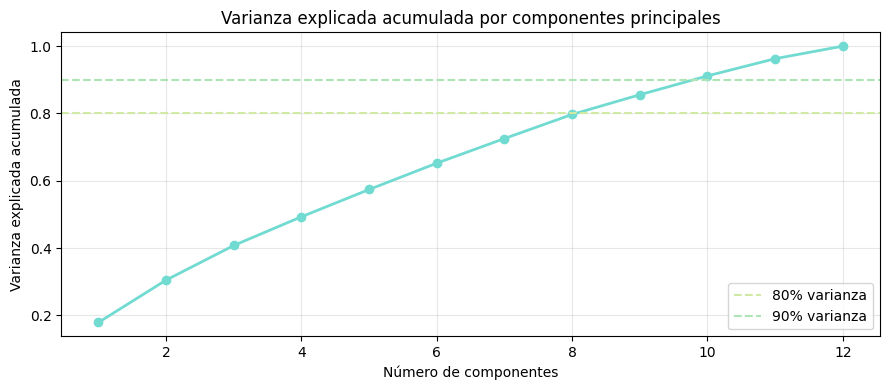

Componentes necesarios para explicar ≥80% de la varianza: 9

Varianza explicada por cada componente:
  PC1: 0.179 (17.9%)
  PC2: 0.126 (12.6%)
  PC3: 0.103 (10.3%)
  PC4: 0.085 (8.5%)
  PC5: 0.081 (8.1%)
  PC6: 0.078 (7.8%)
  PC7: 0.073 (7.3%)
  PC8: 0.072 (7.2%)
  PC9: 0.058 (5.8%)


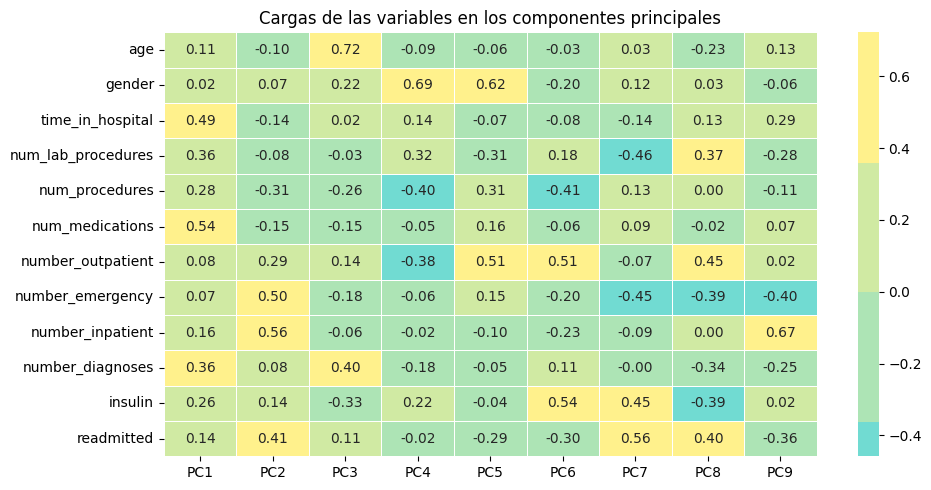

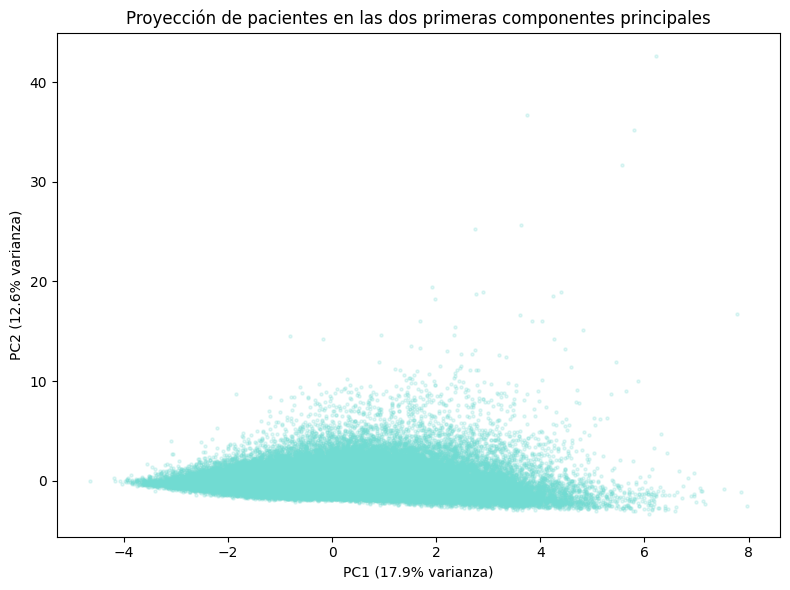

In [53]:
# 4.1 Varianza explicada por componente
pca_full = PCA()
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
         marker='o', color='#71dbd2', linewidth=2, markersize=6)
plt.axhline(y=0.80, color='#d0eaa3', linestyle='--', label='80% varianza')
plt.axhline(y=0.90, color='#ade4b5', linestyle='--', label='90% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por componentes principales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/3.pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

# Número de componentes para el 80% de varianza
n_componentes = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Componentes necesarios para explicar ≥80% de la varianza: {n_componentes}")

# 4.2 Aplicar PCA con n componentes
pca = PCA(n_components=n_componentes, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nVarianza explicada por cada componente:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f} ({v*100:.1f}%)")

# 4.3 Cargas de los componentes (interpretabilidad)
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_cluster.columns,
    columns=[f'PC{i+1}' for i in range(n_componentes)]
)

plt.figure(figsize=(10, 5))
sns.heatmap(loadings, annot=True, fmt=".2f",
            cmap=sns.color_palette(colors, as_cmap=True),
            linewidths=0.5, center=0)
plt.title('Cargas de las variables en los componentes principales')
plt.tight_layout()
plt.savefig('/content/3.pca_cargas.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.4 Visualización 2D (PC1 vs PC2)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            alpha=0.2, s=5, color='#71dbd2')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Proyección de pacientes en las dos primeras componentes principales')
plt.tight_layout()
plt.savefig('/content/3.pca_proyeccion2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Clustering con K-means

K-Means particiona los pacientes en k grupos minimizando la varianza intra-clúster.
Se aplica sobre los componentes principales para mayor estabilidad.

Para elegir k se usan dos criterios complementarios:
- Método del codo
- Índice de silueta

k=2 → Inercia: 906024 | Silueta: 0.1558
k=3 → Inercia: 834052 | Silueta: 0.1402
k=4 → Inercia: 769856 | Silueta: 0.1138
k=5 → Inercia: 717921 | Silueta: 0.1219
k=6 → Inercia: 673682 | Silueta: 0.1288
k=7 → Inercia: 639760 | Silueta: 0.1293
k=8 → Inercia: 612679 | Silueta: 0.1275


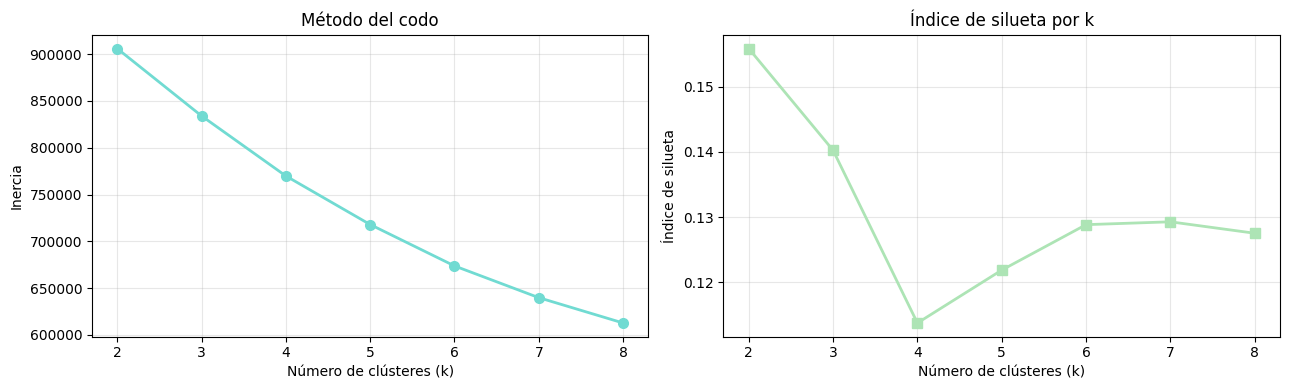


K óptimo seleccionado: 2 (silueta = 0.1558)

Distribución de pacientes por clúster:
cluster
0    62111
1    39655
Name: count, dtype: int64


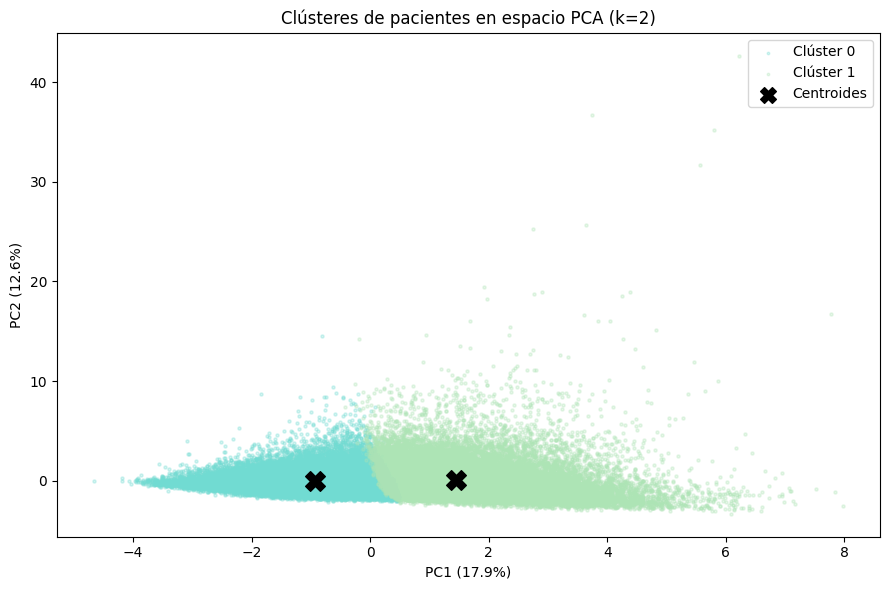

In [69]:
#  5.1 Método del codo + Silueta
inercias = []
siluetas = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_pca, etiquetas, sample_size=10000, random_state=42))
    print(f"k={k} → Inercia: {km.inertia_:.0f} | Silueta: {siluetas[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Codo
axes[0].plot(rango_k, inercias, marker='o', color='#71dbd2', linewidth=2, markersize=7)
axes[0].set_xlabel('Número de clústeres (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].grid(alpha=0.3)

# Silueta
axes[1].plot(rango_k, siluetas, marker='s', color='#ade4b5', linewidth=2, markersize=7)
axes[1].set_xlabel('Número de clústeres (k)')
axes[1].set_ylabel('Índice de silueta')
axes[1].set_title('Índice de silueta por k')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/4.kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.2 Ajuste del modelo final
# Selecciona el k con mayor índice de silueta
k_optimo = list(rango_k)[np.argmax(siluetas)]
print(f"\nK óptimo seleccionado: {k_optimo} (silueta = {max(siluetas):.4f})")

km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_pca)

print("\nDistribución de pacientes por clúster:")
print(df_cluster['cluster'].value_counts().sort_index())

# 5.3 Visualización de clústeres en espacio PCA
cluster_colors = ['#71dbd2', '#ade4b5', '#d0eaa3', '#fff18c',
                  '#176585', '#27b1bf', '#c2e4cb']

plt.figure(figsize=(9, 6))
for c in range(k_optimo):
    mask = df_cluster['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=5, alpha=0.3, label=f'Clúster {c}',
                color=cluster_colors[c])

# Centroides
centroides_pca = km_final.cluster_centers_
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            s=200, marker='X', c='black', zorder=5, label='Centroides')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Clústeres de pacientes en espacio PCA (k={k_optimo})')
plt.legend(markerscale=0.8)
plt.tight_layout()
plt.savefig('/content/4.kmeans_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretación clínica de los perfiles

Resumen de perfiles por clúster:
         n_pacientes  edad_media  pct_femenino  dias_hospitalizacion  lab_procedures  medicamentos  hospitalizaciones_previas  emergencias_previas  n_diagnosticos  readmision_media
cluster                                                                                                                                                                             
0              62111        5.97          0.52                  2.99           36.23         12.19                       0.39                 0.12            6.81              0.46
1              39655        6.29          0.56                  6.60           53.84         22.03                       1.02                 0.31            8.39              0.75


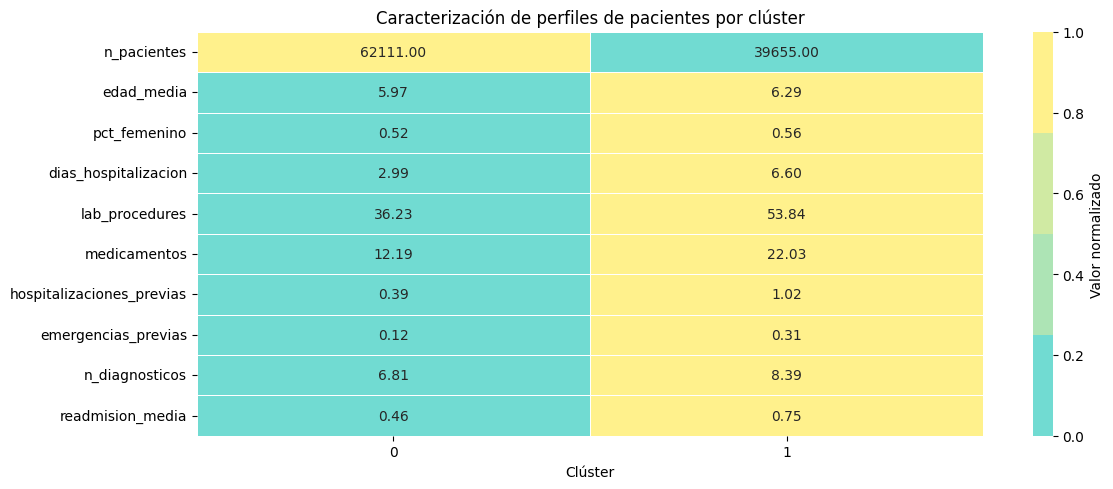

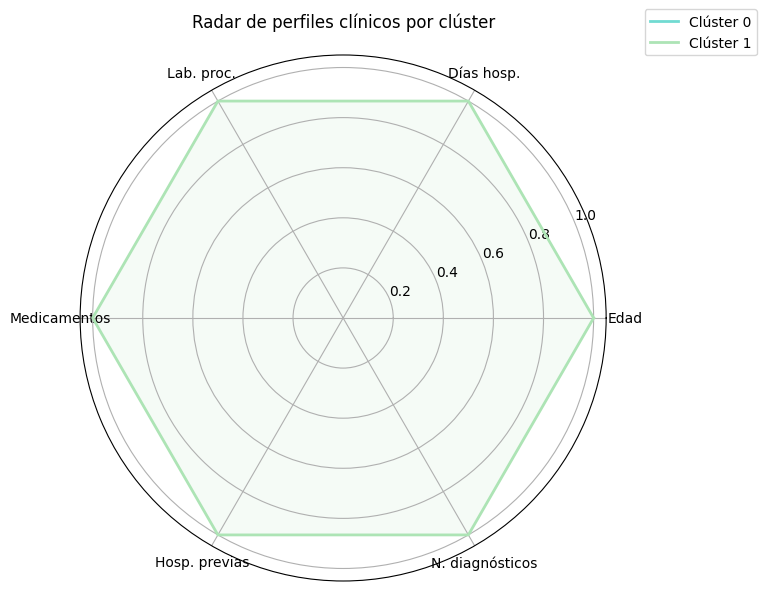

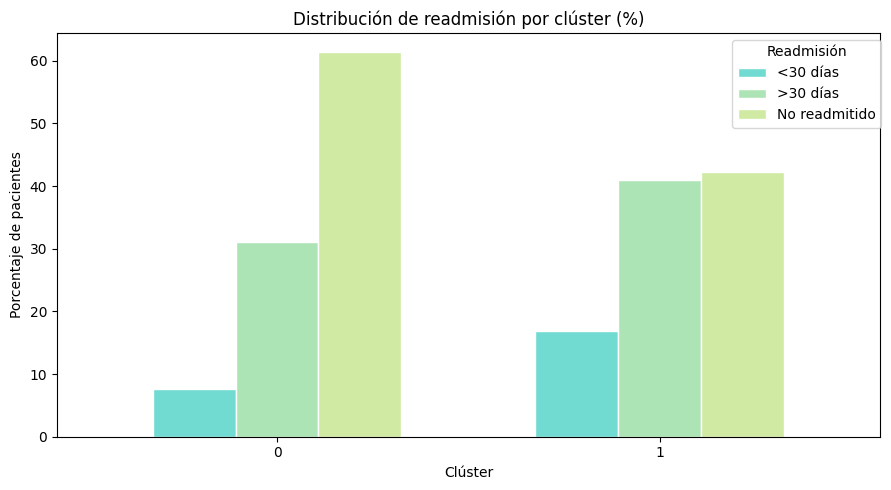

In [55]:
#Caracterización e interpretación de los clústeres
#Cada clúster representa un perfil de paciente con características compartidas.
#A continuación se analiza cada perfil en términos de sus variables clave.

#  6.1 Estadísticas descriptivas por clúster
resumen = df_cluster.groupby('cluster').agg(
    n_pacientes=('cluster', 'count'),
    edad_media=('age', 'mean'),
    pct_femenino=('gender', 'mean'),
    dias_hospitalizacion=('time_in_hospital', 'mean'),
    lab_procedures=('num_lab_procedures', 'mean'),
    medicamentos=('num_medications', 'mean'),
    hospitalizaciones_previas=('number_inpatient', 'mean'),
    emergencias_previas=('number_emergency', 'mean'),
    n_diagnosticos=('number_diagnoses', 'mean'),
    readmision_media=('readmitted', 'mean')
).round(2)

print("Resumen de perfiles por clúster:")
print(resumen.to_string())

# 6.2 Heatmap de perfiles
# Normalizar para comparar en la misma escala
resumen_norm = (resumen - resumen.min()) / (resumen.max() - resumen.min())

plt.figure(figsize=(12, 5))
sns.heatmap(resumen_norm.T, annot=resumen.T, fmt='.2f',
            cmap=sns.color_palette(colors, as_cmap=True),
            linewidths=0.5, cbar_kws={'label': 'Valor normalizado'})
plt.title('Caracterización de perfiles de pacientes por clúster')
plt.xlabel('Clúster')
plt.tight_layout()
plt.savefig('/content/5.perfiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 6.3 Radar chart por clúster
import matplotlib.patches as mpatches
from matplotlib.path import Path

# Variables a visualizar en el radar
radar_vars = ['edad_media', 'dias_hospitalizacion', 'lab_procedures',
              'medicamentos', 'hospitalizaciones_previas', 'n_diagnosticos']

valores_norm = resumen_norm[radar_vars]
N = len(radar_vars)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # cerrar el polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (idx, row) in enumerate(valores_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angulos, vals, linewidth=2,
            color=cluster_colors[i], label=f'Clúster {idx}')
    ax.fill(angulos, vals, alpha=0.12, color=cluster_colors[i])

ax.set_thetagrids(np.degrees(angulos[:-1]),
                  ['Edad', 'Días hosp.', 'Lab. proc.',
                   'Medicamentos', 'Hosp. previas', 'N. diagnósticos'])
ax.set_title('Radar de perfiles clínicos por clúster', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('/content/5.perfiles_radar.png', dpi=150, bbox_inches='tight')
plt.show()

# 6.4 Distribución de readmisión por clúster
readmision_labels = {0: 'No readmitido', 1: '>30 días', 2: '<30 días'}
df_cluster['readmitted_label'] = df_cluster['readmitted'].map(readmision_labels)

plt.figure(figsize=(9, 5))
readm_pct = (df_cluster.groupby(['cluster', 'readmitted_label'])
             .size()
             .unstack(fill_value=0)
             .apply(lambda x: x / x.sum() * 100, axis=1))

readm_pct.plot(kind='bar', ax=plt.gca(),
               color=['#71dbd2', '#ade4b5', '#d0eaa3'],
               edgecolor='white', width=0.65)
plt.title('Distribución de readmisión por clúster (%)')
plt.xlabel('Clúster')
plt.ylabel('Porcentaje de pacientes')
plt.xticks(rotation=0)
plt.legend(title='Readmisión', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('/content/5.perfiles_readmision.png', dpi=150, bbox_inches='tight')
plt.show()

## **Resumen**

In [56]:
print("Análisis de perfiles completado.")
print(f"\nResumen final:")
print(f"  - Pacientes analizados: {len(df_cluster):,}")
print(f"  - Componentes PCA: {n_componentes} (≥80% varianza)")
print(f"  - Clústeres identificados: {k_optimo}")
print(f"  - Índice de silueta final: {max(siluetas):.4f}")

Análisis de perfiles completado.

Resumen final:
  - Pacientes analizados: 101,766
  - Componentes PCA: 9 (≥80% varianza)
  - Clústeres identificados: 2
  - Índice de silueta final: 0.1558
